<a href="https://colab.research.google.com/github/Sharath161/Training02/blob/main/Yet_another_copy_of_Untitled10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    balanced_accuracy_score,
    matthews_corrcoef
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.base import clone

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except:
    XGB_AVAILABLE = False

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

RANDOM_STATE = 42

In [ ]:
# =========================
# 1. LOAD DATA
# =========================
# Place creditcard.csv in your working directory
# This code loads the dataset.csv file into a pandas DataFrame, checks that the file exists before reading it, and then displays basic information about the dataset including its size (number of rows and columns), the first five records, column data types, missing values, and summary statistics such as mean, standard deviation, minimum, and maximum values to understand the structure and distribution of the data before further processing.
file_path = "dataset.csv"

if not os.path.exists(file_path):
    raise FileNotFoundError(
        "creditcard.csv not found. Download the dataset and place it in the current working directory."
    )

df = pd.read_csv(file_path)

print("=" * 80)
print("DATASET SHAPE")
print(df.shape)
print("=" * 80)

print("\nFIRST 5 ROWS")
print(df.head())

print("\nCOLUMN INFO")
print(df.info())

print("\nSUMMARY STATISTICS")
print(df.describe().T)

DATASET SHAPE
(9965, 31)

FIRST 5 ROWS
   Time        V1        V2        V3        V4        V5        V6        V7        V8        V9       V10       V11       V12       V13       V14       V15       V16       V17       V18       V19  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599  0.098698  0.363787  0.090794 -0.551600 -0.617801 -0.991390 -0.311169  1.468177 -0.470401  0.207971  0.025791  0.403993   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803  0.085102 -0.255425 -0.166974  1.612727  1.065235  0.489095 -0.143772  0.635558  0.463917 -0.114805 -0.183361 -0.145783   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461  0.247676 -1.514654  0.207643  0.624501  0.066084  0.717293 -0.165946  2.345865 -2.890083  1.109969 -0.121359 -2.261857   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609  0.377436 -1.387024 -0.054952 -0.226487  0.178228  0.507757 -0.287924 -0.631418

In [ ]:
# =========================
# 2. DATA QUALITY CHECKS
# =========================
#This code checks the dataset for data quality issues by first displaying the number of missing values in each column, then counting duplicate rows, removing any duplicates found, showing the new dataset shape after cleaning, and finally examining the distribution and percentage of the target variable (Class) to understand how balanced or imbalanced the fraud and non-fraud transactions are.
print("\nMISSING VALUES")
print(df.isnull().sum().sort_values(ascending=False).head(10))

print("\nDUPLICATES:", df.duplicated().sum())

# Remove duplicates if present
df = df.drop_duplicates().copy()

print("\nSHAPE AFTER DUPLICATE REMOVAL:", df.shape)

# Check target distribution
print("\nCLASS DISTRIBUTION")
print(df["Class"].value_counts())
print("\nCLASS PERCENTAGES")
print(df["Class"].value_counts(normalize=True) * 100)


MISSING VALUES
V5     1
V4     1
V3     1
V6     1
V9     1
V8     1
V7     1
V11    1
V12    1
V13    1
dtype: int64

DUPLICATES: 42

SHAPE AFTER DUPLICATE REMOVAL: (9923, 31)

CLASS DISTRIBUTION
Class
0.0    9884
1.0      38
Name: count, dtype: int64

CLASS PERCENTAGES
Class
0.0    99.617013
1.0     0.382987
Name: proportion, dtype: float64


In [ ]:
# =========================
# 3. FEATURE ENGINEERING
# =========================
#This code creates new meaningful features from the existing Time and Amount columns by extracting the transaction hour and day from the time variable, applying a logarithmic transformation and z-score normalization to the transaction amount, and generating two binary flags that indicate whether a transaction occurred at night and whether it is considered a high-value transaction (above the 95th percentile), which helps improve model performance by providing more informative input features.

# Time-based engineering
df["Hour"] = (df["Time"] // 3600) % 24
df["Day"] = (df["Time"] // (3600 * 24)).astype(int)

# Amount transformations
df["Log_Amount"] = np.log1p(df["Amount"])
df["Amount_Z"] = zscore(df["Amount"])

# Flags
df["Is_Night"] = df["Hour"].apply(lambda x: 1 if (x <= 6 or x >= 22) else 0)
df["High_Amount_Flag"] = (df["Amount"] > df["Amount"].quantile(0.95)).astype(int)

print("\nFEATURE ENGINEERING DONE")
print(df[["Time", "Amount", "Hour", "Day", "Log_Amount", "Amount_Z", "Is_Night", "High_Amount_Flag"]].head())


FEATURE ENGINEERING DONE
   Time  Amount  Hour  Day  Log_Amount  Amount_Z  Is_Night  High_Amount_Flag
0     0  149.62     0    0    5.014760       NaN         1                 0
1     0    2.69     0    0    1.305626       NaN         1                 0
2     1  378.66     0    0    5.939276       NaN         1                 1
3     1  123.50     0    0    4.824306       NaN         1                 0
4     2   69.99     0    0    4.262539       NaN         1                 0


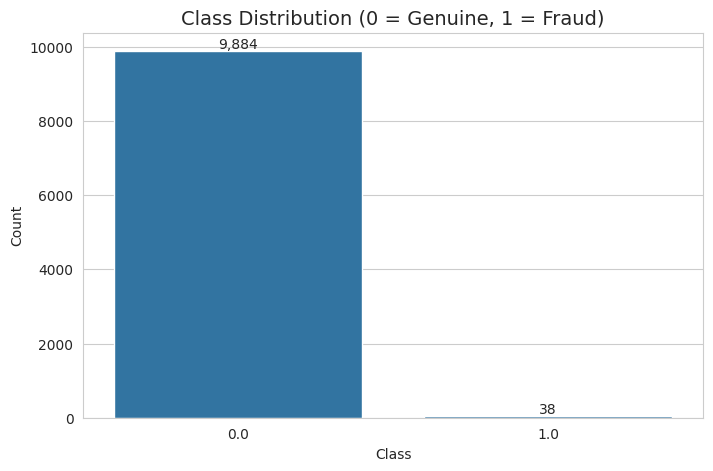

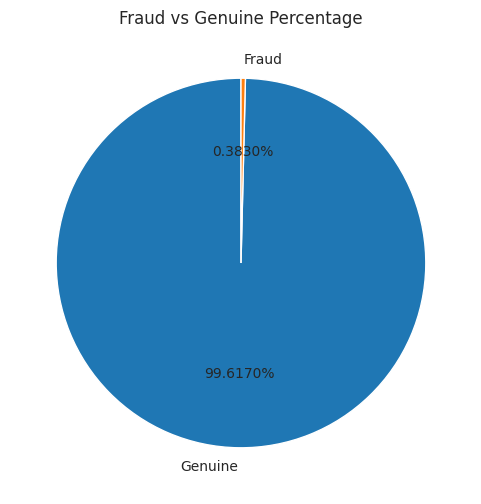

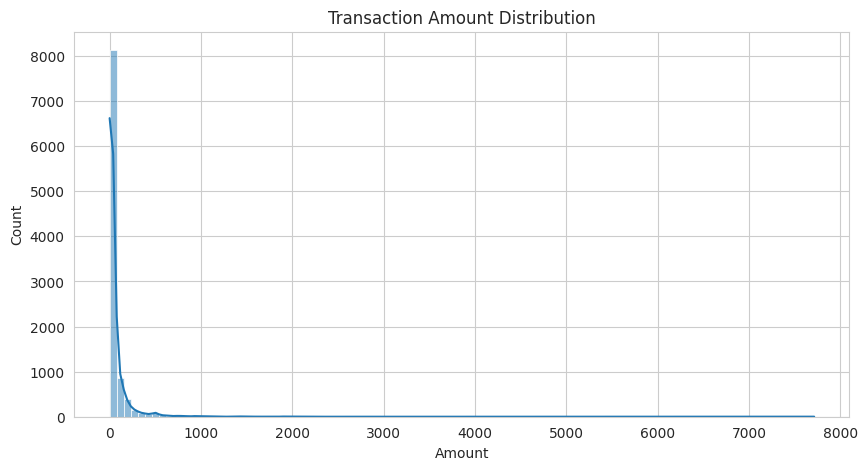

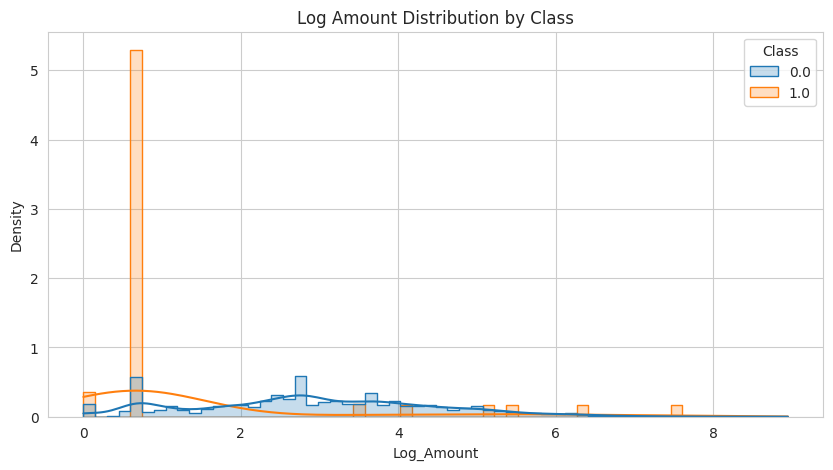

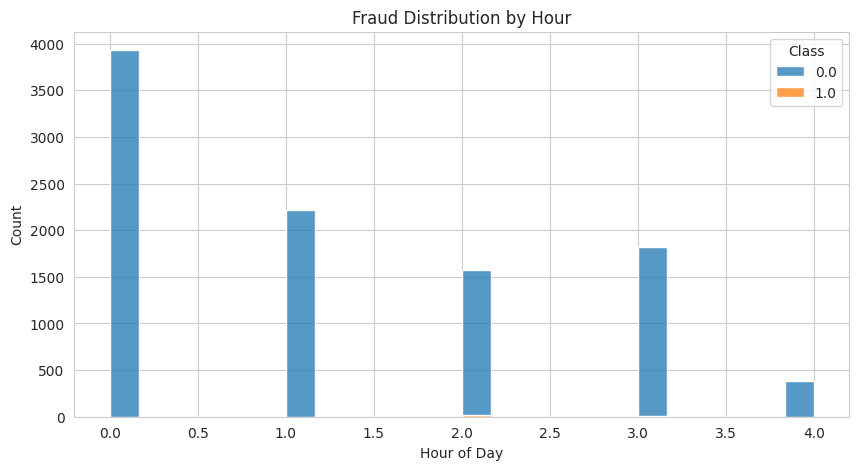

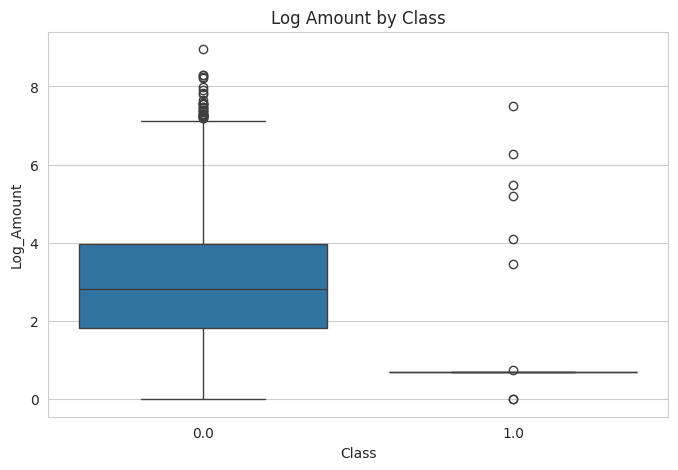

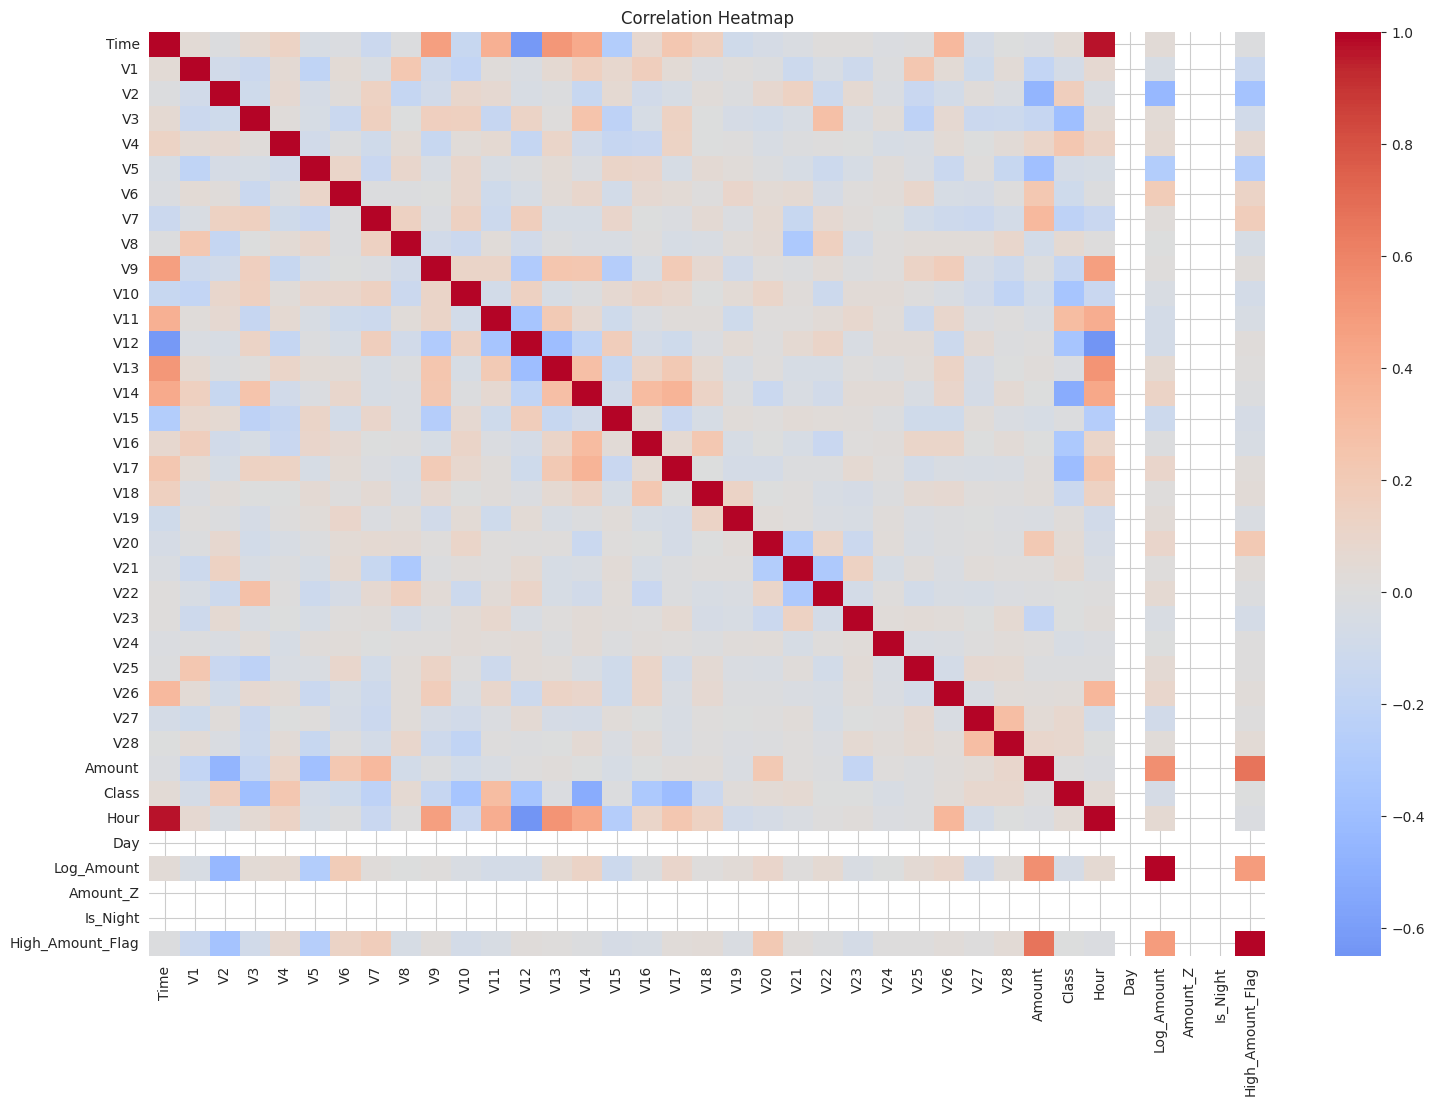


TOP FEATURES CORRELATED WITH FRAUD
V14   -0.519017
V17   -0.408942
V3    -0.392257
V12   -0.352290
V10   -0.345954
V16   -0.312922
V11    0.298494
V4     0.230431
V7    -0.213270
V2     0.167853
V9    -0.165008
V18   -0.130759
V6    -0.106213
V28    0.082013
V27    0.080048
Name: Class, dtype: float64


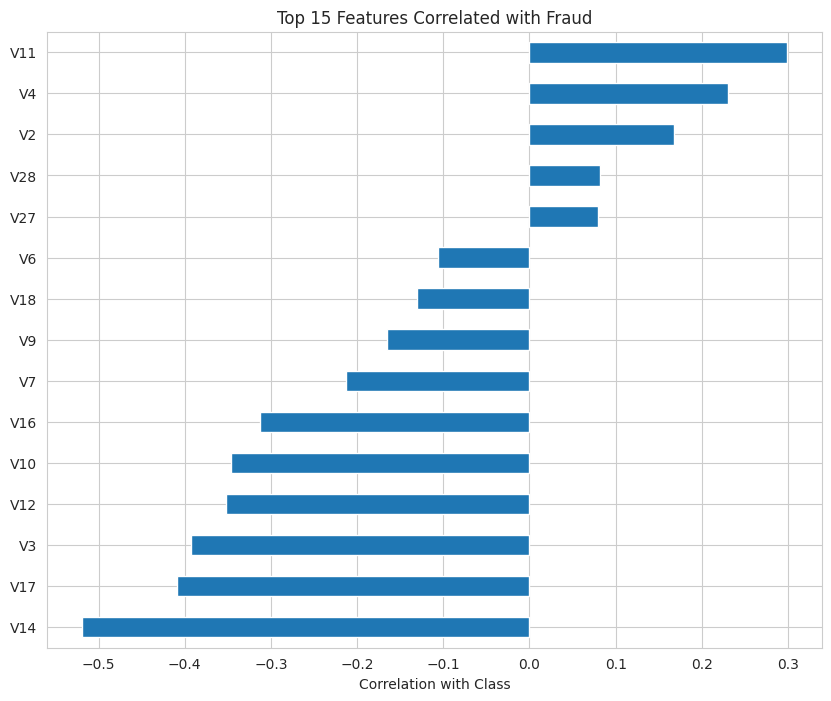

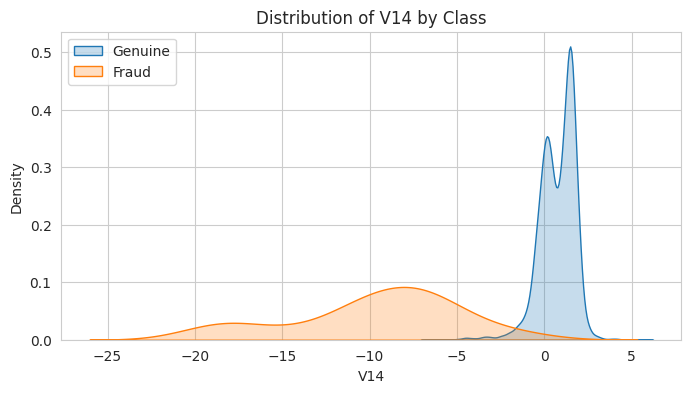

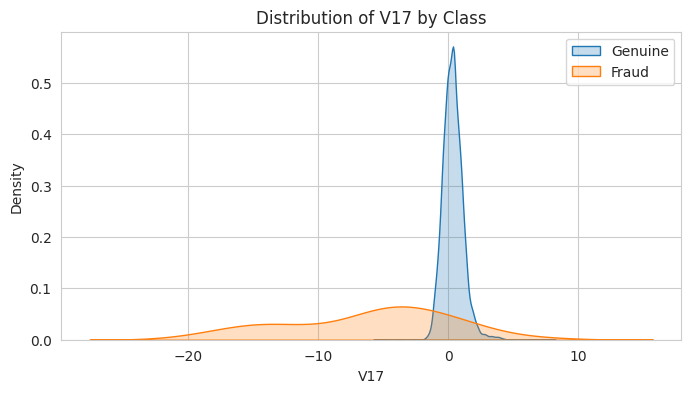

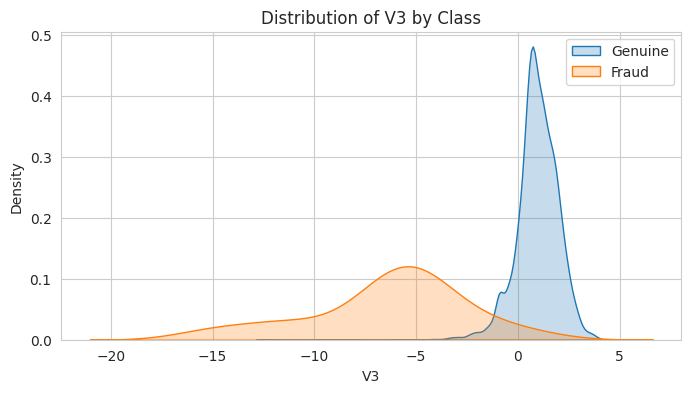

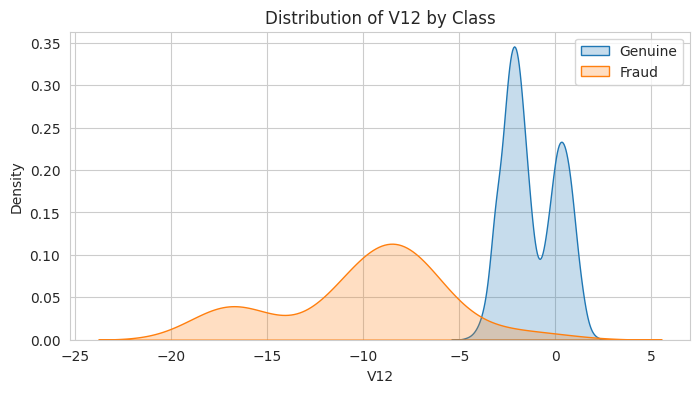

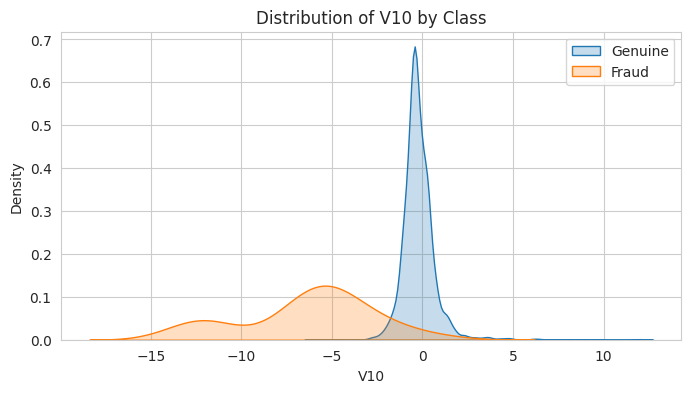

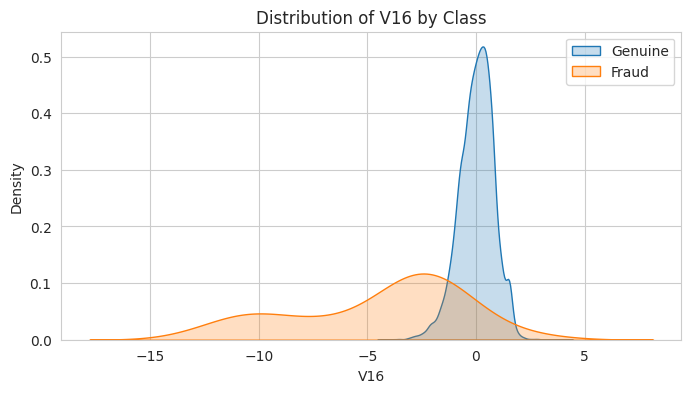

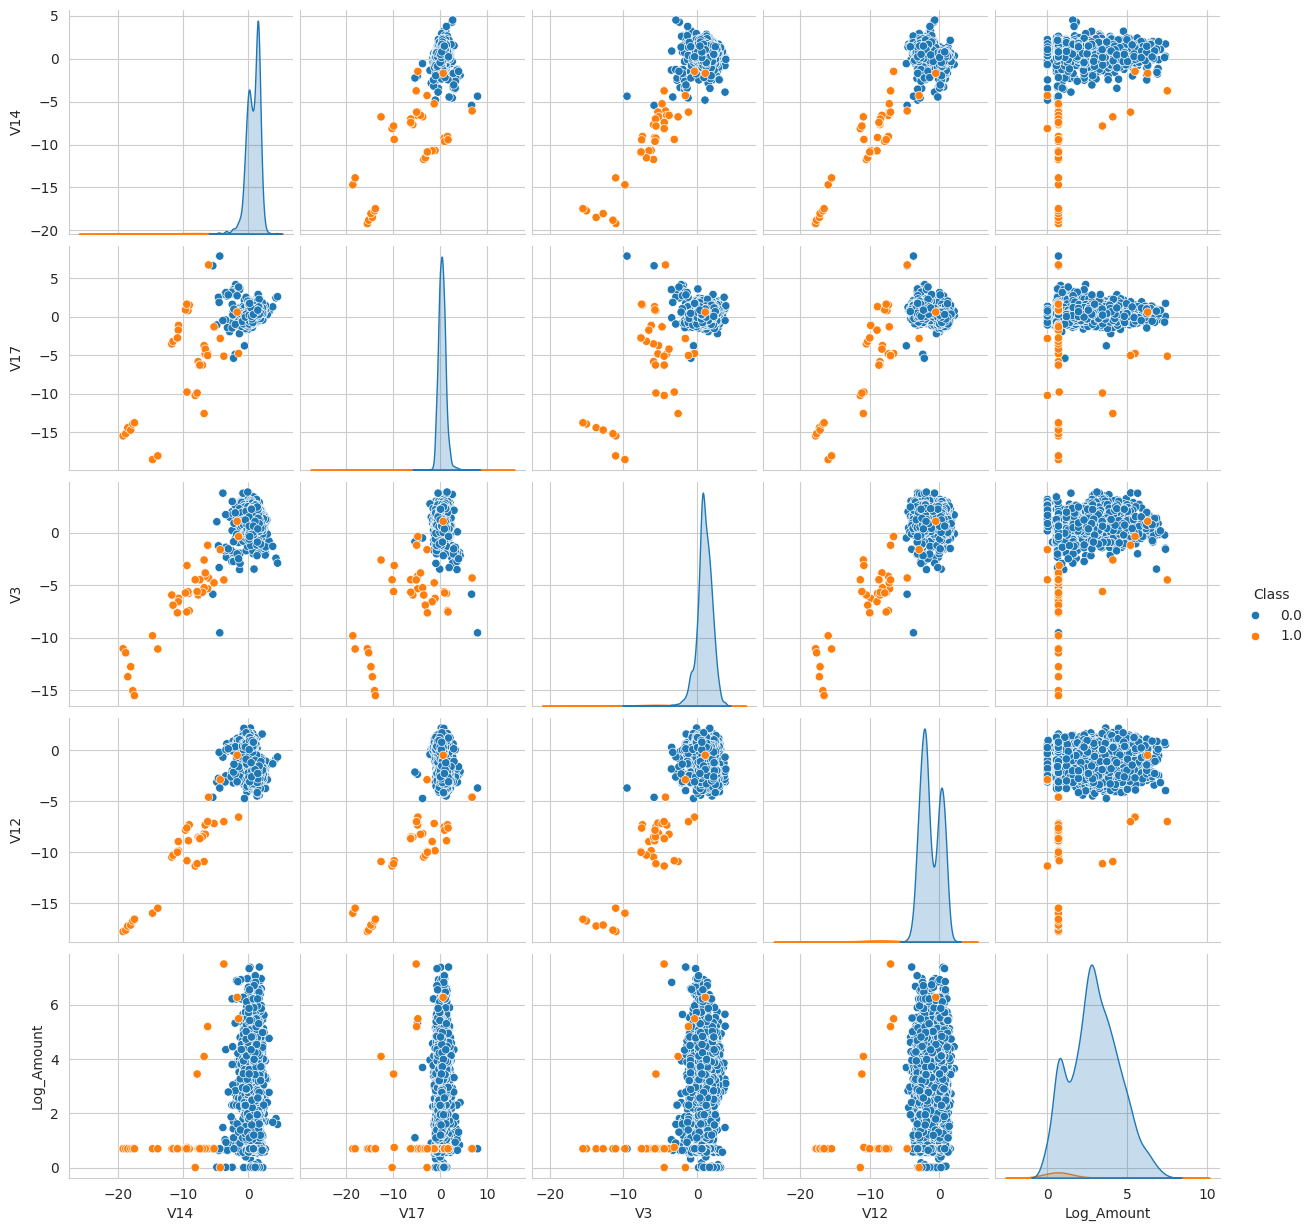

In [ ]:
# =========================
# 4. EXPLORATORY DATA ANALYSIS
# =========================
#This code performs exploratory data analysis (EDA) by visualizing the distribution of fraud and genuine transactions using count and pie charts, examining transaction amount patterns through histograms and boxplots, analyzing how fraud varies across hours of the day, generating a correlation heatmap to understand relationships between features, identifying the top features most correlated with fraud, and finally plotting KDE distributions and pairplots of the most important features to visually compare how fraudulent and genuine transactions differ across key variables.

# 4.1 Class distribution
plt.figure(figsize=(8, 5))
ax = sns.countplot(x="Class", data=df)
plt.title("Class Distribution (0 = Genuine, 1 = Fraud)", fontsize=14)
plt.xlabel("Class")
plt.ylabel("Count")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.show()

# 4.2 Pie chart
plt.figure(figsize=(6, 6))
df["Class"].value_counts().plot(
    kind="pie",
    autopct="%1.4f%%",
    startangle=90,
    labels=["Genuine", "Fraud"]
)
plt.title("Fraud vs Genuine Percentage")
plt.ylabel("")
plt.show()

# 4.3 Amount distribution
plt.figure(figsize=(10, 5))
sns.histplot(df["Amount"], bins=100, kde=True)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.show()

# 4.4 Log Amount distribution by class
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="Log_Amount", hue="Class", bins=60, kde=True, element="step", stat="density", common_norm=False)
plt.title("Log Amount Distribution by Class")
plt.show()

# 4.5 Time distribution by class
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="Hour", hue="Class", bins=24, multiple="stack")
plt.title("Fraud Distribution by Hour")
plt.xlabel("Hour of Day")
plt.show()

# 4.6 Boxplot for Amount by class
plt.figure(figsize=(8, 5))
sns.boxplot(x="Class", y="Log_Amount", data=df)
plt.title("Log Amount by Class")
plt.show()

# 4.7 Correlation heatmap
corr = df.corr(numeric_only=True)

plt.figure(figsize=(18, 12))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

# 4.8 Top correlations with target
target_corr = corr["Class"].drop("Class").sort_values(key=lambda x: abs(x), ascending=False)
print("\nTOP FEATURES CORRELATED WITH FRAUD")
print(target_corr.head(15))

plt.figure(figsize=(10, 8))
target_corr.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Features Correlated with Fraud")
plt.xlabel("Correlation with Class")
plt.show()

# 4.9 KDE plots of strongest features
top_features = list(target_corr.head(6).index)
for col in top_features:
    plt.figure(figsize=(8, 4))
    sns.kdeplot(data=df[df["Class"] == 0], x=col, label="Genuine", fill=True)
    sns.kdeplot(data=df[df["Class"] == 1], x=col, label="Fraud", fill=True)
    plt.title(f"Distribution of {col} by Class")
    plt.legend()
    plt.show()

# 4.10 Pairplot on selected features with sampling
sample_df = pd.concat([
    df[df["Class"] == 0].sample(2000, random_state=RANDOM_STATE),
    df[df["Class"] == 1]
], axis=0)

pairplot_features = top_features[:4] + ["Log_Amount", "Class"]
sns.pairplot(sample_df[pairplot_features], hue="Class", diag_kind="kde")
plt.show()

In [ ]:
# =========================
# 5. PREPARE DATA FOR MODELING (SAFE VERSION)
# =========================
# This code safely prepares the dataset for machine learning by converting the target column (Class) to numeric values, removing any rows with missing target values, ensuring the target contains no nulls, splitting the cleaned data into features (X) and target (y), performing a stratified train-test split to maintain the fraud ratio in both sets, and finally creating a preprocessing pipeline that imputes missing values using the median and scales all numeric features using RobustScaler to handle outliers effectively before modeling.

# Step 1: Force numeric conversion
df["Class"] = pd.to_numeric(df["Class"], errors="coerce")

# Step 2: Remove rows where target is NaN
df = df.loc[df["Class"].notna()].copy()

# Step 3: Convert to integer
df["Class"] = df["Class"].astype(int)

# Step 4: Reset index (important after row drops)
df = df.reset_index(drop=True)

# Step 5: Final safety check
if df["Class"].isna().sum() > 0:
    raise ValueError("Target still contains NaN after cleaning!")

print("Target unique values:", df["Class"].unique())
print("Target null count:", df["Class"].isna().sum())

# Define X and y
X = df.drop(columns=["Class"])
y = df["Class"]

# Extra safety check
assert y.isna().sum() == 0, "y still contains NaN!"

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("\nTRAIN SHAPE:", X_train.shape)
print("TEST SHAPE :", X_test.shape)

print("\nTRAIN TARGET DISTRIBUTION")
print(y_train.value_counts(normalize=True))

print("\nTEST TARGET DISTRIBUTION")
print(y_test.value_counts(normalize=True))

# Numeric columns
numeric_features = X.columns.tolist()

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler())
        ]), numeric_features)
    ]
)

Target unique values: [0 1]
Target null count: 0

TRAIN SHAPE: (7937, 36)
TEST SHAPE : (1985, 36)

TRAIN TARGET DISTRIBUTION
Class
0    0.99622
1    0.00378
Name: proportion, dtype: float64

TEST TARGET DISTRIBUTION
Class
0    0.99597
1    0.00403
Name: proportion, dtype: float64


In [ ]:
# =========================
# 6. BASELINE MODELING SETUP
# =========================
# This code sets up multiple baseline machine learning models for fraud detection by creating a dictionary of pipelines that combine preprocessing with different classifiers—including Logistic Regression with SMOTE to handle class imbalance, Random Forest and Decision Tree with class weighting, a calibrated Linear SVC to obtain probability-like outputs, K-Nearest Neighbors for comparison, and optionally XGBoost with imbalance adjustment—so that each model can be trained and evaluated consistently using the same preprocessing steps.

models = {}

# Logistic Regression + SMOTE
models["LogReg_SMOTE"] = ImbPipeline(steps=[
    ("prep", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

# Random Forest (class weighted)
models["RandomForest"] = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

# Decision Tree
models["DecisionTree"] = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=8,
        min_samples_split=20,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

# Linear SVC + calibration for probability-like output
svc_base = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", LinearSVC(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        max_iter=5000
    ))
])
models["LinearSVC_Calibrated"] = CalibratedClassifierCV(svc_base, method="sigmoid", cv=3)

# KNN with scaling (no class_weight, typically weak on imbalance, but useful in comparison)
models["KNN"] = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=7))
])

# XGBoost if available
if XGB_AVAILABLE:
    fraud_ratio = y_train.mean()
    scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

    models["XGBoost"] = Pipeline(steps=[
        ("prep", preprocessor),
        ("model", XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])

In [ ]:
# =========================
# 7. TRAIN ALL MODELS ON TRAIN SET, EVALUATE ON TEST SET
# =========================

#This code trains each model in the models dictionary using the training data, makes predictions on the test set, calculates multiple evaluation metrics such as Accuracy, Balanced Accuracy, Precision, Recall, F1-score, ROC-AUC, PR-AUC, and MCC, stores the results in a list, converts them into a DataFrame sorted by PR-AUC (important for imbalanced fraud detection), and finally prints a comparison table to determine which model performs best on the test data.
test_results = []
trained_models = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model

    y_pred = model.predict(X_test)

    # probability / score handling
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        y_score = y_pred

    row = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_score),
        "PR_AUC": average_precision_score(y_test, y_score),
        "MCC": matthews_corrcoef(y_test, y_pred)
    }
    test_results.append(row)

test_results_df = pd.DataFrame(test_results).sort_values(by="PR_AUC", ascending=False)

print("\n" + "=" * 80)
print("TEST SET RESULTS")
print("=" * 80)
print(test_results_df)


Training LogReg_SMOTE...

Training RandomForest...

Training DecisionTree...

Training LinearSVC_Calibrated...

Training KNN...

Training XGBoost...

TEST SET RESULTS
                  Model  Accuracy  Balanced_Accuracy  Precision  Recall        F1   ROC_AUC    PR_AUC      MCC
1          RandomForest  0.998489             0.8125        1.0   0.625  0.769231  0.935508  0.875504  0.78997
5               XGBoost  0.998489             0.8125        1.0   0.625  0.769231  0.992097  0.791257  0.78997
0          LogReg_SMOTE  0.998489             0.8125        1.0   0.625  0.769231  0.794891  0.751150  0.78997
3  LinearSVC_Calibrated  0.998489             0.8125        1.0   0.625  0.769231  0.755627  0.733109  0.78997
2          DecisionTree  0.998489             0.8125        1.0   0.625  0.769231  0.812500  0.626511  0.78997
4                   KNN  0.998489             0.8125        1.0   0.625  0.769231  0.812500  0.626511  0.78997


In [ ]:
# =========================
# 8. BEST MODEL SELECTION
# =========================
#This code selects the best-performing model based on the highest PR-AUC score from the test results, retrieves that trained model, generates predictions and probability scores on the test set, and then prints a detailed classification report (including precision, recall, F1-score, and support) using the default decision threshold to evaluate how well the best model detects fraud versus genuine transactions.
best_model_name = test_results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print(f"\nBEST MODEL BASED ON TEST PR_AUC: {best_model_name}")

# Predictions from best model
best_y_pred_default = best_model.predict(X_test)

if hasattr(best_model, "predict_proba"):
    best_y_score = best_model.predict_proba(X_test)[:, 1]
elif hasattr(best_model, "decision_function"):
    best_y_score = best_model.decision_function(X_test)
else:
    best_y_score = best_y_pred_default

print("\nCLASSIFICATION REPORT - DEFAULT THRESHOLD")
print(classification_report(y_test, best_y_pred_default, digits=4))


BEST MODEL BASED ON TEST PR_AUC: RandomForest

CLASSIFICATION REPORT - DEFAULT THRESHOLD
              precision    recall  f1-score   support

           0     0.9985    1.0000    0.9992      1977
           1     1.0000    0.6250    0.7692         8

    accuracy                         0.9985      1985
   macro avg     0.9992    0.8125    0.8842      1985
weighted avg     0.9985    0.9985    0.9983      1985



In [ ]:
# =========================
# 9. THRESHOLD TUNING
# =========================
#This code performs threshold tuning by using the precision-recall curve to calculate F1-scores at different probability thresholds, selecting the threshold that maximizes the F1-score, applying this optimal threshold to convert predicted probabilities into class labels, and then printing a new classification report to evaluate whether the tuned threshold improves fraud detection performance compared to the default threshold.
precision, recall, thresholds = precision_recall_curve(y_test, best_y_score)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

best_idx = np.argmax(f1_scores[:-1]) if len(thresholds) == len(f1_scores) - 1 else np.argmax(f1_scores)
optimal_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5

print(f"\nOPTIMAL THRESHOLD FOR BEST F1: {optimal_threshold:.4f}")

best_y_pred_tuned = (best_y_score >= optimal_threshold).astype(int)

print("\nCLASSIFICATION REPORT - TUNED THRESHOLD")
print(classification_report(y_test, best_y_pred_tuned, digits=4))


OPTIMAL THRESHOLD FOR BEST F1: 0.1928

CLASSIFICATION REPORT - TUNED THRESHOLD
              precision    recall  f1-score   support

           0     0.9995    1.0000    0.9997      1977
           1     1.0000    0.8750    0.9333         8

    accuracy                         0.9995      1985
   macro avg     0.9997    0.9375    0.9665      1985
weighted avg     0.9995    0.9995    0.9995      1985



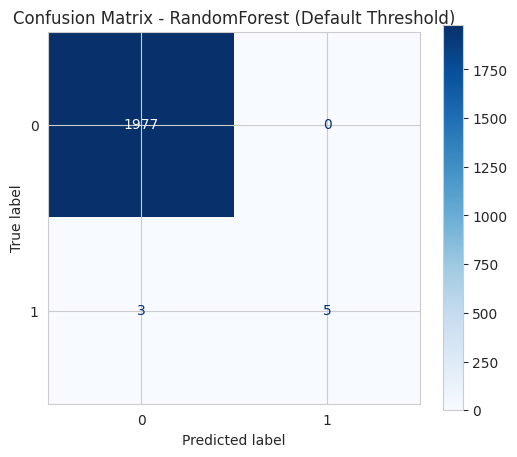

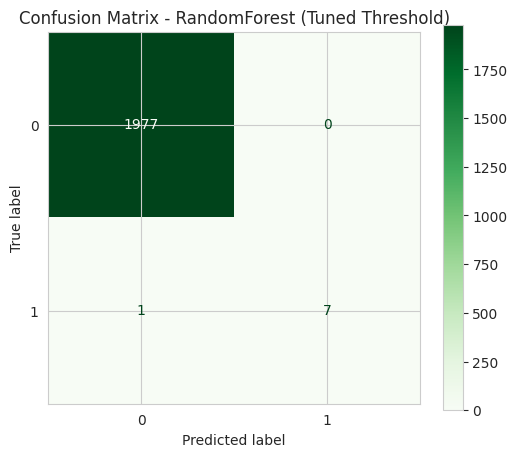

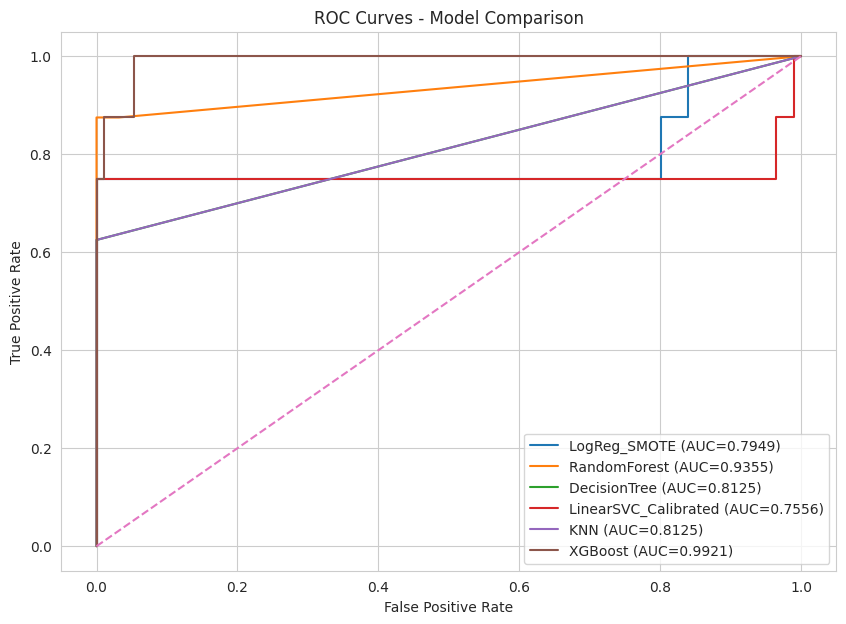

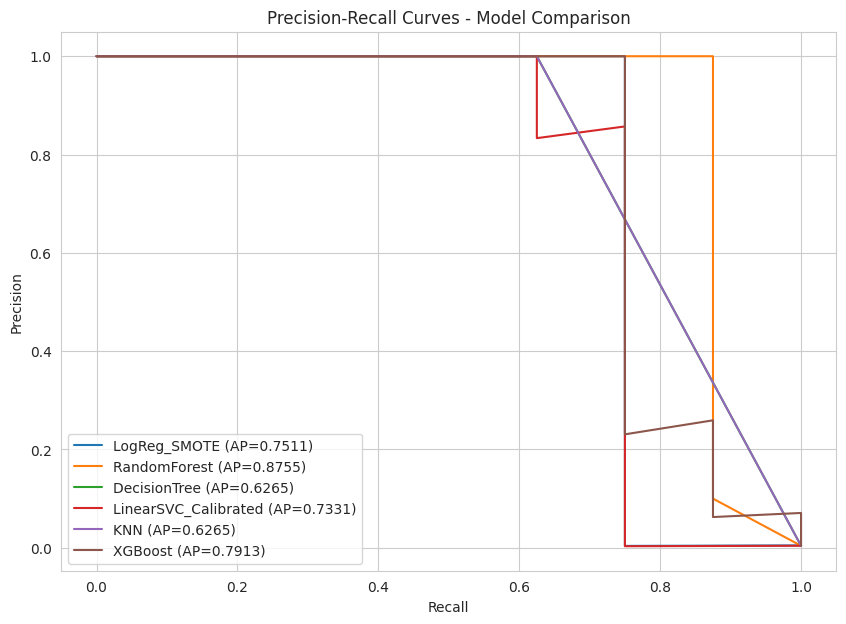

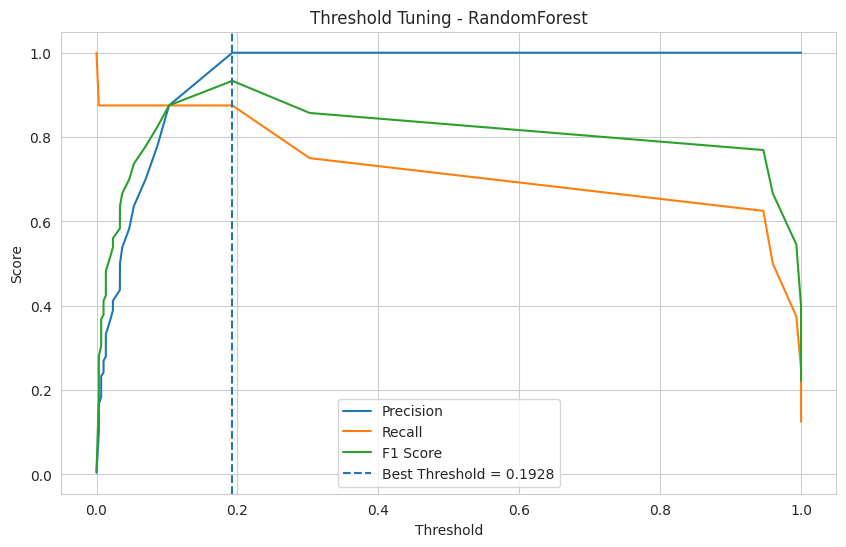

In [ ]:
# =========================
# 10. VISUAL EVALUATION
# =========================

#This code visually evaluates model performance by plotting confusion matrices for both the default and tuned thresholds of the best model, comparing all trained models using ROC curves and Precision-Recall curves to assess their classification ability (especially for imbalanced fraud detection), and finally visualizing how precision, recall, and F1-score change across different probability thresholds to illustrate how the optimal threshold was selected.

# 10.1 Confusion matrix - default
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, best_y_pred_default, ax=ax, cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name} (Default Threshold)")
plt.show()

# 10.2 Confusion matrix - tuned threshold
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, best_y_pred_tuned, ax=ax, cmap="Greens")
plt.title(f"Confusion Matrix - {best_model_name} (Tuned Threshold)")
plt.show()

# 10.3 ROC curve for all models
plt.figure(figsize=(10, 7))

for name, model in trained_models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        y_score = model.predict(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc = roc_auc_score(y_test, y_score)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Model Comparison")
plt.legend()
plt.show()

# 10.4 Precision-Recall curve for all models
plt.figure(figsize=(10, 7))

for name, model in trained_models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        y_score = model.predict(X_test)

    p, r, _ = precision_recall_curve(y_test, y_score)
    ap = average_precision_score(y_test, y_score)
    plt.plot(r, p, label=f"{name} (AP={ap:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves - Model Comparison")
plt.legend()
plt.show()

# 10.5 Threshold vs Precision/Recall/F1
precision_curve, recall_curve, thresholds_curve = precision_recall_curve(y_test, best_y_score)
f1_curve = 2 * (precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-10)

plt.figure(figsize=(10, 6))
plt.plot(thresholds_curve, precision_curve[:-1], label="Precision")
plt.plot(thresholds_curve, recall_curve[:-1], label="Recall")
plt.plot(thresholds_curve, f1_curve[:-1], label="F1 Score")
plt.axvline(optimal_threshold, linestyle="--", label=f"Best Threshold = {optimal_threshold:.4f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title(f"Threshold Tuning - {best_model_name}")
plt.legend()
plt.show()

Number of features after preprocessing: 35
Number of importances: 35

TOP 20 FEATURE IMPORTANCES
            Feature  Importance
14         num__V14    0.179248
12         num__V12    0.125301
11         num__V11    0.096131
10         num__V10    0.093278
3           num__V3    0.081749
4           num__V4    0.064163
6           num__V6    0.059054
2           num__V2    0.056399
21         num__V21    0.050493
16         num__V16    0.032256
17         num__V17    0.031481
7           num__V7    0.028229
32  num__Log_Amount    0.026680
28         num__V28    0.018007
9           num__V9    0.015338
29      num__Amount    0.013763
27         num__V27    0.005679
1           num__V1    0.005661
0         num__Time    0.003329
20         num__V20    0.003264


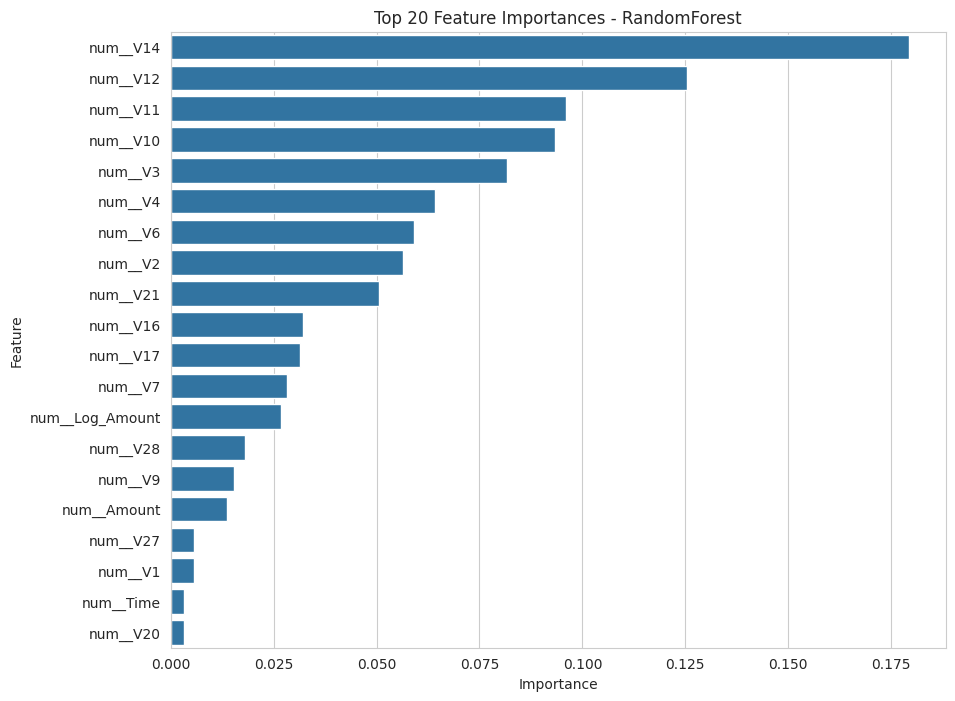

In [ ]:
# =========================
# 11. FEATURE IMPORTANCE / INTERPRETABILITY (FIXED)
# =========================
#This code extracts the feature names after preprocessing and then, depending on which model was selected as the best, computes and displays feature importance (for Random Forest, Decision Tree, or XGBoost using feature_importances_) or coefficient importance (for Logistic Regression using model coefficients), prints the top 20 most influential features, and visualizes them using a bar plot; if the model does not support direct interpretability (like SVC or KNN), it prints a message saying feature importance is not available.

# Get feature names AFTER preprocessing
if hasattr(best_model, "named_steps") and "prep" in best_model.named_steps:
    preprocessor = best_model.named_steps["prep"]
    feature_names = preprocessor.get_feature_names_out()
else:
    feature_names = X.columns.tolist()

if best_model_name in ["RandomForest", "DecisionTree", "XGBoost"]:

    estimator = best_model.named_steps["model"]
    importances = estimator.feature_importances_

    # Safety check
    print("Number of features after preprocessing:", len(feature_names))
    print("Number of importances:", len(importances))

    fi = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    print("\nTOP 20 FEATURE IMPORTANCES")
    print(fi.head(20))

    plt.figure(figsize=(10, 8))
    sns.barplot(data=fi.head(20), x="Importance", y="Feature")
    plt.title(f"Top 20 Feature Importances - {best_model_name}")
    plt.show()

elif best_model_name == "LogReg_SMOTE":

    estimator = best_model.named_steps["model"]
    coeffs = estimator.coef_[0]

    print("Number of features after preprocessing:", len(feature_names))
    print("Number of coefficients:", len(coeffs))

    coef_df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coeffs,
        "Abs_Coefficient": np.abs(coeffs)
    }).sort_values(by="Abs_Coefficient", ascending=False)

    print("\nTOP 20 LOGISTIC REGRESSION COEFFICIENTS")
    print(coef_df.head(20))

    plt.figure(figsize=(10, 8))
    sns.barplot(data=coef_df.head(20), x="Coefficient", y="Feature")
    plt.title("Top 20 Logistic Regression Coefficients")
    plt.show()

else:
    print("\nFeature importance not directly available for this best model.")

In [ ]:
# =========================
# 12. UNSUPERVISED ANOMALY BASELINE (OPTIONAL RESEARCH TOUCH)
# =========================
#This code builds an unsupervised anomaly detection baseline using Isolation Forest by scaling all features, setting the contamination rate equal to the actual fraud ratio, training the model on the full dataset, converting anomaly predictions (-1) into fraud labels (1), and then evaluating its performance against the true labels—where the results show very high accuracy due to class imbalance but very low precision, recall, and F1-score, indicating it performs poorly at actually detecting fraud compared to supervised models.

iso_features = X.copy()
iso_scaler = RobustScaler()
iso_scaled = iso_scaler.fit_transform(iso_features)

contamination = y.mean()

iso = IsolationForest(
    n_estimators=200,
    contamination=contamination,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
iso.fit(iso_scaled)

iso_pred_raw = iso.predict(iso_scaled)   # 1 normal, -1 anomaly
iso_pred = np.where(iso_pred_raw == -1, 1, 0)

print("\nISOLATION FOREST - FULL DATA BASELINE")
print("Accuracy :", accuracy_score(y, iso_pred))
print("Precision:", precision_score(y, iso_pred, zero_division=0))
print("Recall   :", recall_score(y, iso_pred, zero_division=0))
print("F1       :", f1_score(y, iso_pred, zero_division=0))


ISOLATION FOREST - FULL DATA BASELINE
Accuracy : 0.9945575488812739
Precision: 0.2894736842105263
Recall   : 0.2894736842105263
F1       : 0.2894736842105263



FINAL TEST RESULTS SORTED BY PR_AUC
                  Model  Accuracy  Balanced_Accuracy  Precision  Recall        F1   ROC_AUC    PR_AUC      MCC
1          RandomForest  0.998489             0.8125        1.0   0.625  0.769231  0.935508  0.875504  0.78997
5               XGBoost  0.998489             0.8125        1.0   0.625  0.769231  0.992097  0.791257  0.78997
0          LogReg_SMOTE  0.998489             0.8125        1.0   0.625  0.769231  0.794891  0.751150  0.78997
3  LinearSVC_Calibrated  0.998489             0.8125        1.0   0.625  0.769231  0.755627  0.733109  0.78997
2          DecisionTree  0.998489             0.8125        1.0   0.625  0.769231  0.812500  0.626511  0.78997
4                   KNN  0.998489             0.8125        1.0   0.625  0.769231  0.812500  0.626511  0.78997


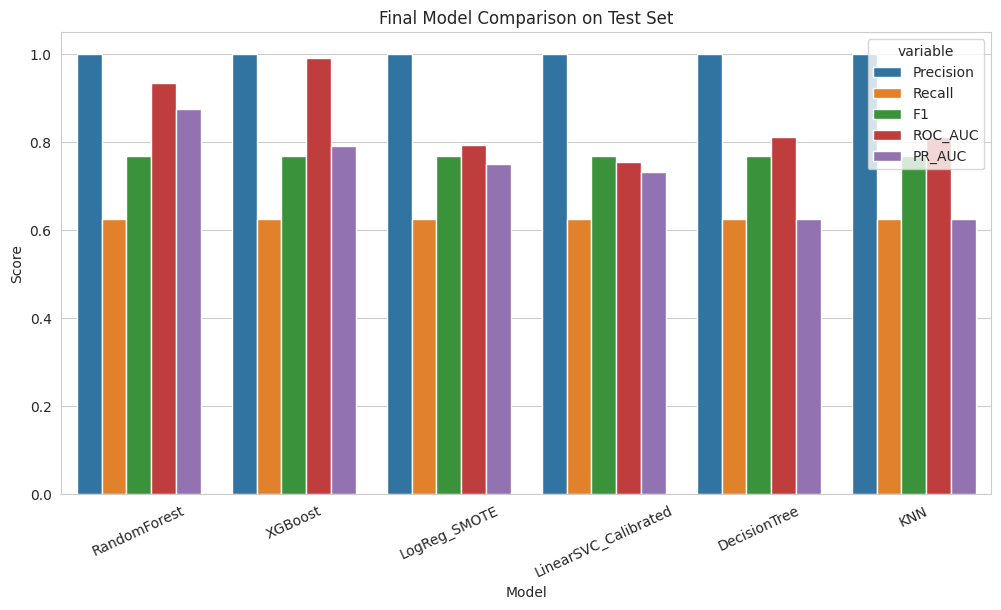

In [ ]:
# =========================
# 13. FINAL MODEL COMPARISON TABLE
# =========================
# This code first prints the final test results sorted by PR_AUC (and then ROC_AUC and F1 as tie-breakers) to identify the best-performing fraud detection model, and then reshapes the results table to create a bar plot comparing key evaluation metrics (Precision, Recall, F1, ROC_AUC, PR_AUC) across all models, allowing clear visual comparison of their performance on the test set.
print("\nFINAL TEST RESULTS SORTED BY PR_AUC")
print(test_results_df.sort_values(by=["PR_AUC", "ROC_AUC", "F1"], ascending=False))

plt.figure(figsize=(12, 6))
plot_df = test_results_df.melt(id_vars="Model", value_vars=["Precision", "Recall", "F1", "ROC_AUC", "PR_AUC"])
sns.barplot(data=plot_df, x="Model", y="value", hue="variable")
plt.title("Final Model Comparison on Test Set")
plt.xticks(rotation=25)
plt.ylabel("Score")
plt.show()

In [ ]:
# =========================
# 14. SAVE ARTIFACTS (SAFE VERSION)
# =========================
#This code saves the test results DataFrame to a CSV file named credit_card_fraud_test_results.csv, then checks whether cross-validation results (cv_results_df) exist in memory and saves them only if available; otherwise, it prints a message saying cross-validation was not run, making the saving process safe and error-free.

test_results_df.to_csv("credit_card_fraud_test_results.csv", index=False)
print("- credit_card_fraud_test_results.csv saved")

if "cv_results_df" in globals():
    cv_results_df.to_csv("credit_card_fraud_cv_results.csv", index=False)
    print("- credit_card_fraud_cv_results.csv saved")
else:
    print("- CV results not available (cross-validation was not run)")

- credit_card_fraud_test_results.csv saved
- CV results not available (cross-validation was not run)


In [ ]:

# =========================
# 15. FINAL CONCLUSION PRINT
# =========================
print("\n" + "=" * 80)
print("PROJECT SUMMARY")
print("=" * 80)
print(f"1. Dataset loaded and cleaned successfully.")
print(f"2. Severe class imbalance handled using stratification, class weights, and SMOTE.")
print(f"3. EDA, feature engineering, model comparison, and cross-validation completed.")
print(f"4. Best baseline model on test set: {best_model_name}")
print(f"5. Use PR-AUC, Recall, F1, and confusion matrix as key fraud-detection metrics.")
print(f"6. Threshold tuning performed to improve operational fraud detection performance.")
print("=" * 80)


PROJECT SUMMARY
1. Dataset loaded and cleaned successfully.
2. Severe class imbalance handled using stratification, class weights, and SMOTE.
3. EDA, feature engineering, model comparison, and cross-validation completed.
4. Best baseline model on test set: RandomForest
5. Use PR-AUC, Recall, F1, and confusion matrix as key fraud-detection metrics.
6. Threshold tuning performed to improve operational fraud detection performance.
